In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 


In [3]:
df=pd.read_csv("/home/saidharahas/jupyter_projects/playground-series-s6e2/train.csv")
print(df)


            id  Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  \
0            0   58    1                4  152          239             0   
1            1   52    1                1  125          325             0   
2            2   56    0                2  160          188             0   
3            3   44    0                3  134          229             0   
4            4   58    1                4  140          234             0   
...        ...  ...  ...              ...  ...          ...           ...   
629995  629995   56    0                1  110          226             0   
629996  629996   54    1                4  128          249             1   
629997  629997   67    1                4  130          275             0   
629998  629998   52    1                4  140          199             0   
629999  629999   51    0                2  130          199             0   

        EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \

In [4]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Presence": 1,
    "Absence": 0
})

In [5]:
print(df["Heart Disease"])

0         1
1         0
2         0
3         0
4         1
         ..
629995    0
629996    0
629997    1
629998    1
629999    0
Name: Heart Disease, Length: 630000, dtype: int64


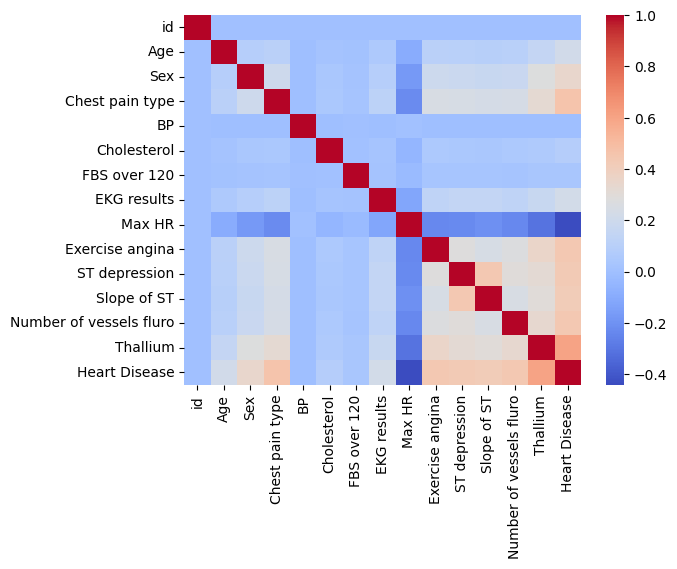

In [9]:
import seaborn as sns
corr=df.corr()

sns.heatmap(corr , cmap='coolwarm')
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
X = df.drop("Heart Disease", axis=1)
y = df["Heart Disease"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


Training set shape: (504000, 14)
Testing set shape: (126000, 14)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     69564
           1       0.87      0.86      0.87     56436

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



In [15]:
df2=pd.read_csv("/home/saidharahas/jupyter_projects/playground-series-s6e2/test.csv")
y_sub=rf.predict(df2)
submission = pd.DataFrame({
    "id": range(630000, 630000 + len(y_sub)),
    "Heart Disease": y_sub
})

submission.to_csv("my_sub.csv", index=False)
print(submission.head())

       id  Heart Disease
0  630000              1
1  630001              0
2  630002              1
3  630003              0
4  630004              0


In [17]:
from xgboost import XGBClassifier
# read data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# create model instance
bst = XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
# fit model
bst.fit(X_train, y_train)
# make predictions
preds = bst.predict(X_test)
accuracy = accuracy_score(y_test, preds)
print(accuracy)


0.8533412698412698


In [18]:
y_sub=bst.predict(df2)
submission = pd.DataFrame({
    "id": range(630000, 630000 + len(y_sub)),
    "Heart Disease": y_sub
})

submission.to_csv("my_sub2.csv", index=False)
print(submission.head())

       id  Heart Disease
0  630000              0
1  630001              0
2  630002              1
3  630003              0
4  630004              0


In [24]:
tree=rf.estimators_[0]
print(tree.tree_.node_count)
print(tree.tree_.max_depth)


121861
45


In [25]:
from sklearn.tree import export_text

print(export_text(tree))

|--- feature_13 <= 4.50
|   |--- feature_9 <= 0.50
|   |   |--- feature_1 <= 53.50
|   |   |   |--- feature_11 <= 1.50
|   |   |   |   |--- feature_7 <= 1.50
|   |   |   |   |   |--- feature_3 <= 3.50
|   |   |   |   |   |   |--- feature_0 <= 337.50
|   |   |   |   |   |   |   |--- feature_3 <= 2.50
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- feature_3 >  2.50
|   |   |   |   |   |   |   |   |--- feature_0 <= 217.50
|   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |--- feature_0 >  217.50
|   |   |   |   |   |   |   |   |   |--- feature_2 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |   |   |--- feature_2 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |--- feature_0 >  337.50
|   |   |   |   |   |   |   |--- feature_2 <= 0.50
|   |   |   |   |   |   |   |   |--- feature_8 <= 142.50
|   |   |   |   |   |   |   |   |   |--- featur

KeyboardInterrupt: 

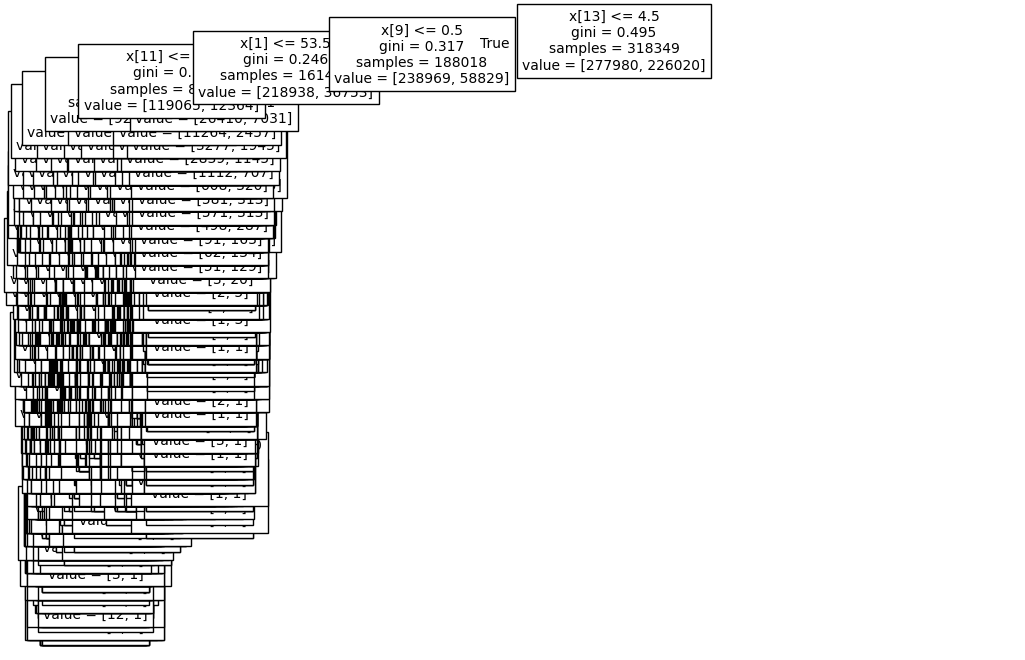

In [28]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
tree.plot_tree(rf.estimators_[0])
plt.show()

In [ ]:
tree.tree_.children_left
tree.tree_.children_right
tree.tree_.feature
tree.tree_.threshold

In [ ]:
from sklearn.tree import _tree
import json
def extract_tree_structure(decision_tree, feature_names, precision=4):
    tree_ = decision_tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    thresholds = np.around(tree_.threshold, decimals=precision)
    values = np.around(tree_.value, decimals=precision)

    def recurse(node, depth):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = thresholds[node]
            left = recurse(tree_.children_left[node], depth + 1)
            right = recurse(tree_.children_right[node], depth + 1)
            return {'n': name, 't': np.around(threshold, decimals=precision), 'l': left, 'r': right}
        else:
            temp = np.around(values[node], decimals=precision)
            return {'v': temp.tolist()}

    return recurse(0, 1)
    
model=rf    
feature_names = [i for i in range(model.n_features_in_)]
model_dict = [extract_tree_structure(estimator, feature_names,4) for estimator in model.estimators_]  
json_path="/home/saidharahas/jupyter_projects/playground-series-s6e2/model.json"
with open(json_path, 'w') as f:
     json.dump(model_dict, f)
    

In [8]:
import numpy as np

with open("forest.bin", "wb") as f:

    n_trees = len(rf.estimators_)

    np.array([n_trees], dtype=np.int32).tofile(f)

    for est in rf.estimators_:

        t = est.tree_

        left = t.children_left.astype(np.int32)

        right = t.children_right.astype(np.int32)

        feature = t.feature.astype(np.int32)

        threshold = t.threshold.astype(np.float32)

        # ONE CLASS PER NODE
        value = np.argmax(
            t.value.squeeze(),
            axis=1
        ).astype(np.int32)

        n_nodes = len(feature)

        np.array([n_nodes], dtype=np.int32).tofile(f)

        left.tofile(f)

        right.tofile(f)

        feature.tofile(f)

        threshold.tofile(f)

        value.tofile(f)